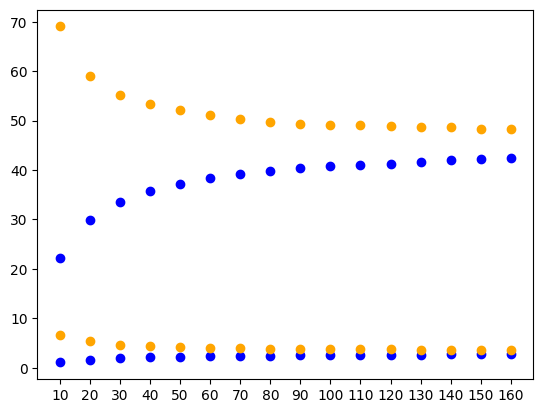

In [3]:
from glob import glob
from pathlib import Path
import json

ROOT = Path("sample_efficiency")

backbone_list = ['mace_mh/0', 'mace_mh/1']

results = {}

for backbone in backbone_list:
    results[backbone] = {}

    for best_json in sorted( ROOT.glob(f"{backbone}/*/run_*/best.json") , key=lambda x: int(x.parts[-3]) ): 
        n = best_json.parts[-3]

        with best_json.open("r") as f:
            data = json.load(f)

        train_forces_mae = data["metrics"]["train"]["forces_MAE"] 
        valid_forces_mae = data["metrics"]["validation"]["forces_MAE"] 

        results[backbone][n] = {
            "train_forces_MAE": train_forces_mae,
            "valid_forces_MAE": valid_forces_mae,
        }

import matplotlib.pyplot as plt

for backbone in results.keys():
    for n in results[backbone].keys():
        plt.scatter(n, results[backbone][n]["train_forces_MAE"], label="train", color="blue")
        plt.scatter(n, results[backbone][n]["valid_forces_MAE"], label="validation", color="orange")

#plt.yscale("log")